In [1]:
import h5py as h5
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

In [2]:
# data_dict['K562'] = h5py.File(self.data_folder + '/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')
# self.data_dict['GM12878'] = h5py.File(self.data_folder + '/GM12878_DNase_ENCFF020WZB_2kb_4DNFI1UEG1HD_promoter_enhancer_encoding.h5', 'r')
data_h5 = h5.File('../data/K562_DNase_ENCFF257HEE_2kb_4DNFITUOMFUQ_enhancer_promoter_encoding.h5', 'r')

In [3]:
data_h5.keys()

<KeysViewHDF5 ['activity', 'distance', 'ensid', 'hic', 'pe_code']>

In [4]:
idx = 100
sample_ensid = data_h5['ensid'][idx].decode()
sample_ensid

'ENSG00000005513'

In [5]:
enhancer_intensity = data_h5['activity'][idx,1:]
enhancer_intensity

array([0.212398, 0.262438, 0.237029, 6.06713 , 1.051706, 0.150271,
       0.583098, 0.307499, 0.524444, 0.270791, 0.386226, 0.248012,
       0.334427, 0.279128, 0.32579 , 0.493826, 0.260607, 0.127631,
       0.287463, 0.207245, 0.221224, 0.297277, 0.204524, 0.312753,
       0.289241, 0.232839, 0.318156, 0.112687, 0.351051, 0.143523,
       0.272057, 0.167365, 0.297542, 0.347299, 0.395042, 0.562525,
       0.174737, 0.291795, 0.318281, 0.320304, 0.398554, 0.436749,
       0.123629, 0.227371, 0.376045, 0.23425 , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ,
       0.      , 0.      , 0.      , 0.      , 0.      , 0.      ])

In [6]:
enhancer_preds = pd.read_csv('../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/Gene-enhancer links/EnhancerPredictions.txt', sep='\t')
#enhancer_preds = pd.read_csv('../data/K562_enhancer_gene_links_100kb.tsv', sep='\t')
enhancer_preds = enhancer_preds.rename(columns={'#chr': 'chr'})
enhancer_preds

,chr,start,end,name,TargetGene,TargetGeneTSS,CellType,ABC.Score
0,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000177706,192570,K562,0.004602
1,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000197461,519217,K562,0.000001
2,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000188191,712475,K562,0.000001
3,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164818,726698,K562,0.000588
4,chr7,31006,31710,intergenic|chr7:31006-31710,ENSG00000164828,816642,K562,0.000000
...,...,...,...,...,...,...,...,...
2294541,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000119574,58519796,K562,0.012138
2294542,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130726,58544455,K562,0.004453
2294543,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130724,58555104,K562,0.013500
2294544,chr19,58584250,58585301,intergenic|chr19:58584250-58585301,ENSG00000130725,58558921,K562,0.013500


In [7]:
sample_info = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid][['chr', 'start', 'end', 'name', 'TargetGeneTSS']]
sample_info

,chr,start,end,name,TargetGeneTSS
1366804,chr16,34514,35288,intergenic|chr16:34514-35288,981769
1366852,chr16,38777,39277,intergenic|chr16:38777-39277,981769
1366900,chr16,41957,42457,intergenic|chr16:41957-42457,981769
1366948,chr16,47022,47733,genic|chr16:47022-47733,981769
1366996,chr16,47986,48570,genic|chr16:47986-48570,981769
...,...,...,...,...,...
1386800,chr16,1944203,1944703,intergenic|chr16:1944203-1944703,981769
1386874,chr16,1945900,1946515,intergenic|chr16:1945900-1946515,981769
1386948,chr16,1952530,1953344,intergenic|chr16:1952530-1953344,981769
1387022,chr16,1960610,1962029,genic|chr16:1960610-1962029,981769


In [8]:
max_distance_down = 0
max_distance_up = 0
for i, row in sample_info.iterrows():
    down_distance = row['start'] - row['TargetGeneTSS']
    up_distance = row['TargetGeneTSS'] - row['end']
    if down_distance > max_distance_down:
        max_distance_down = down_distance
    if up_distance > max_distance_up:
        max_distance_up = up_distance
print(f'Max distance down: {max_distance_down}, Max distance up: {max_distance_up}')

Max distance down: 982213, Max distance up: 946481


In [9]:
enhancer_list = pd.read_csv("../data/K562_DNase_ENCFF257HEE_hic_4DNFITUOMFUQ_1MB_ABC_nominated/DNase_ENCFF257HEE_Neighborhoods/EnhancerList.txt", sep='\t')
enhancer_list = enhancer_list[['chr', 'start', 'end', 'name', 'activity_base', 'activity_base_no_qnorm']]
enhancer_list

,chr,start,end,name,activity_base,activity_base_no_qnorm
0,chr1,585952,586452,intergenic|chr1:585952-586452,0.088073,0.088073
1,chr1,605341,605841,intergenic|chr1:605341-605841,0.355894,0.355894
2,chr1,629686,630186,intergenic|chr1:629686-630186,0.690581,0.690581
3,chr1,633778,634278,intergenic|chr1:633778-634278,1.575716,1.575716
4,chr1,778388,779144,intergenic|chr1:778388-779144,8.205368,8.205368
...,...,...,...,...,...,...
116664,chrY,11329663,11330163,intergenic|chrY:11329663-11330163,0.931987,0.931987
116665,chrY,11333773,11334507,intergenic|chrY:11333773-11334507,0.434642,0.434642
116666,chrY,11712120,11712620,intergenic|chrY:11712120-11712620,0.044362,0.044362
116667,chrY,56849825,56850381,intergenic|chrY:56849825-56850381,0.406223,0.406223


In [10]:
region_names = set(sample_info['name'].values)

enhancer_list_sample = enhancer_list[enhancer_list['name'].isin(region_names)]
enhancer_list_sample

,chr,start,end,name,activity_base,activity_base_no_qnorm
86875,chr16,34514,35288,intergenic|chr16:34514-35288,0.609633,0.609633
86876,chr16,38777,39277,intergenic|chr16:38777-39277,0.433853,0.433853
86877,chr16,41957,42457,intergenic|chr16:41957-42457,1.161634,1.161634
86878,chr16,47022,47733,genic|chr16:47022-47733,0.562404,0.562404
86879,chr16,47986,48570,genic|chr16:47986-48570,0.574033,0.574033
...,...,...,...,...,...,...
87213,chr16,1944203,1944703,intergenic|chr16:1944203-1944703,0.557722,0.557722
87214,chr16,1945900,1946515,intergenic|chr16:1945900-1946515,0.577529,0.577529
87215,chr16,1952530,1953344,intergenic|chr16:1952530-1953344,0.446117,0.446117
87217,chr16,1960610,1962029,genic|chr16:1960610-1962029,3.486609,3.486609


In [11]:
sample_match = []
for i, row in enhancer_list_sample.iterrows():
    # check if value appears anywhere in the enhancer_intensity
    if row['activity_base'] in enhancer_intensity:
        # check if it has already been matched
        if row['activity_base'] in sample_match:
            print(f"Duplicate match found for {row['activity_base']}")
            sample_match.append(np.nan)
        if row['activity_base'] not in sample_match:
            sample_match.append(row['activity_base'])
    else:
        sample_match.append(np.nan)

enhancer_list_sample['known_activity'] = sample_match
enhancer_list_sample['used'] = enhancer_list_sample['known_activity'].notna()
enhancer_list_sample

Duplicate match found for 0.262438


/tmp/ipykernel_2344476/1779143456.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enhancer_list_sample['known_activity'] = sample_match
/tmp/ipykernel_2344476/1779143456.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enhancer_list_sample['used'] = enhancer_list_sample['known_activity'].notna()


,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,used
86875,chr16,34514,35288,intergenic|chr16:34514-35288,0.609633,0.609633,NaN,False
86876,chr16,38777,39277,intergenic|chr16:38777-39277,0.433853,0.433853,NaN,False
86877,chr16,41957,42457,intergenic|chr16:41957-42457,1.161634,1.161634,NaN,False
86878,chr16,47022,47733,genic|chr16:47022-47733,0.562404,0.562404,NaN,False
86879,chr16,47986,48570,genic|chr16:47986-48570,0.574033,0.574033,NaN,False
...,...,...,...,...,...,...,...,...
87213,chr16,1944203,1944703,intergenic|chr16:1944203-1944703,0.557722,0.557722,NaN,False
87214,chr16,1945900,1946515,intergenic|chr16:1945900-1946515,0.577529,0.577529,NaN,False
87215,chr16,1952530,1953344,intergenic|chr16:1952530-1953344,0.446117,0.446117,NaN,False
87217,chr16,1960610,1962029,genic|chr16:1960610-1962029,3.486609,3.486609,NaN,False


In [12]:
sample_tss = enhancer_preds[enhancer_preds['TargetGene'] == sample_ensid]['TargetGeneTSS'].values[0]
distance_to_tss = []
for i, row in enhancer_list_sample.iterrows():
    if sample_tss > row['start']:
        distance = row['end'] - sample_tss
    else:
        distance = row['start'] - sample_tss
    distance_to_tss.append(distance)

enhancer_list_sample['distance_to_tss'] = distance_to_tss
enhancer_list_sample

/tmp/ipykernel_2344476/136517399.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  enhancer_list_sample['distance_to_tss'] = distance_to_tss


,chr,start,end,name,activity_base,activity_base_no_qnorm,known_activity,used,distance_to_tss
86875,chr16,34514,35288,intergenic|chr16:34514-35288,0.609633,0.609633,NaN,False,-946481
86876,chr16,38777,39277,intergenic|chr16:38777-39277,0.433853,0.433853,NaN,False,-942492
86877,chr16,41957,42457,intergenic|chr16:41957-42457,1.161634,1.161634,NaN,False,-939312
86878,chr16,47022,47733,genic|chr16:47022-47733,0.562404,0.562404,NaN,False,-934036
86879,chr16,47986,48570,genic|chr16:47986-48570,0.574033,0.574033,NaN,False,-933199
...,...,...,...,...,...,...,...,...,...
87213,chr16,1944203,1944703,intergenic|chr16:1944203-1944703,0.557722,0.557722,NaN,False,962434
87214,chr16,1945900,1946515,intergenic|chr16:1945900-1946515,0.577529,0.577529,NaN,False,964131
87215,chr16,1952530,1953344,intergenic|chr16:1952530-1953344,0.446117,0.446117,NaN,False,970761
87217,chr16,1960610,1962029,genic|chr16:1960610-1962029,3.486609,3.486609,NaN,False,978841


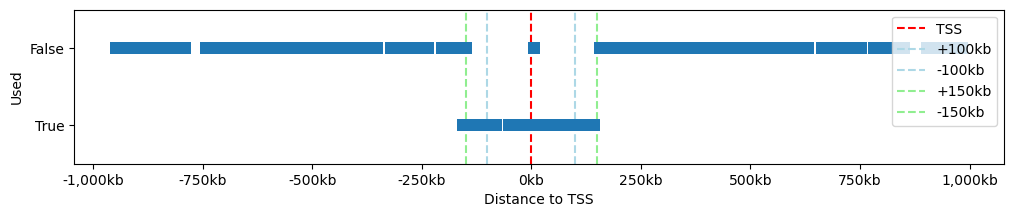

In [13]:
fig, ax = plt.subplots(figsize=(12, 2))
sns.stripplot(data=enhancer_list_sample, x='distance_to_tss', y='used', ax=ax, jitter=False, size=8, marker='s', orient='h')
# vertical line at 0
ax.axvline(x=0, color='red', linestyle='--', label='TSS')
ax.axvline(x=100_000, color='lightblue', linestyle='--', label='+100kb')
ax.axvline(x=-100_000, color='lightblue', linestyle='--', label='-100kb')
ax.axvline(x=150_000, color='lightgreen', linestyle='--', label='+150kb')
ax.axvline(x=-150_000, color='lightgreen', linestyle='--', label='-150kb')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda y, pos: '{:,.0f}'.format(y/1000) + 'kb'))
ax.set_xlabel('Distance to TSS')
ax.set_ylabel('Used')
ax.legend()
plt.show()